# Copper Spot Price Forecasting - Kaggle Edition (Weekly / 5-day horizon)

Daily bars (`freq="B"`) with a **5-trading-day ("weekly") primary horizon**.
Shares the `src/` engine with the monthly notebook; wired with the v2
forecast-quality upgrades (overlap-aware & deflated Sharpe, Diebold-Mariano
gate, robust model selection, RobustCombiner, vol-normalised target option).


## 0. Environment Setup

In [1]:
# ── Clone the repo (skip if already present) ──────────────────────────────
import os, subprocess, sys

REPO_URL  = 'https://github.com/ferhat00/copper-forecast.git'
REPO_DIR  = '/kaggle/working/copper-forecast'
BRANCH    = os.environ.get('REPO_BRANCH', 'main')


def _git(*args, cwd=None):
    out = subprocess.run(['git', *args], cwd=cwd, capture_output=True, text=True)
    if out.returncode != 0:
        raise RuntimeError(f"git {' '.join(args)} failed:\n{out.stderr}")
    return out.stdout


if not os.path.isdir(REPO_DIR):
    _git('clone', '--depth', '1', '--branch', BRANCH, REPO_URL, REPO_DIR)
    print(f'Cloned {BRANCH} OK')
else:
    print(f'Repo already present — fetching {BRANCH}…')
    _git('fetch', '--depth', '1', 'origin', BRANCH, cwd=REPO_DIR)
    _git('checkout', '-B', BRANCH, f'origin/{BRANCH}', cwd=REPO_DIR)
    print(f'On branch {BRANCH}, synced to origin/{BRANCH}.')

sha = _git('rev-parse', '--short', 'HEAD', cwd=REPO_DIR).strip()
print(f'HEAD: {BRANCH} @ {sha}')

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
print(f'Working directory: {os.getcwd()}')


Cloned main OK
HEAD: main @ a6daebd
Working directory: /kaggle/working/copper-forecast


In [2]:
# ── Install / upgrade required packages ───────────────────────────────────
import subprocess, sys

_PKGS = [
    'yfinance>=0.2.36',
    'fredapi>=0.5.1',
    'prophet>=1.1.5',
    'hmmlearn>=0.3.0',
    'statsmodels>=0.14.0',
    'optuna>=3.4.0',
    'shap>=0.43.0',
    'kaleido==0.2.1',
    'akshare>=1.13.0',     # LME/SHFE inventories — graceful skip if install fails
    'pyyaml>=6.0',
]

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade'] + _PKGS,
    check=False,           # akshare may fail on Kaggle — we degrade gracefully
)
print('Packages installed (akshare optional — pipeline will skip inventory if absent).')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 38.6 MB/s eta 0:00:00
Packages installed (akshare optional — pipeline will skip inventory if absent).


In [3]:
!pip install plotly

In [4]:
# ── Detect GPU and configure accelerator flags ────────────────────────────
import subprocess

def _has_gpu() -> bool:
    try:
        out = subprocess.run(
            ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
            capture_output=True, text=True, timeout=5
        )
        return out.returncode == 0 and out.stdout.strip() != ''
    except FileNotFoundError:
        return False

GPU_AVAILABLE = _has_gpu()
XGB_DEVICE   = 'cuda' if GPU_AVAILABLE else 'cpu'
XGB_METHOD   = 'hist'
LGB_DEVICE   = 'gpu' if GPU_AVAILABLE else 'cpu'

import os
N_JOBS = int(os.cpu_count() or 2)

print(f'GPU available : {GPU_AVAILABLE}')
print(f'XGBoost device: {XGB_DEVICE} | tree_method: {XGB_METHOD}')
print(f'LightGBM device: {LGB_DEVICE}')
print(f'Parallel jobs : {N_JOBS}')


GPU available : False
XGBoost device: cpu | tree_method: hist
LightGBM device: cpu
Parallel jobs : 4


## 1. Setup & Configuration

In [5]:
import warnings
import logging
import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')

from src.data_ingestion import load_data
from src.feature_engineering import build_features, split_features_targets
from src.models import (
    NaiveModel, LinearModel, ElasticNetModel, CuratedForecaster,
    XGBoostModel, LGBMModel, EnsembleModel,
    QuantileForecaster, BaseForecaster,
)
from src.models_stacking import StackingEnsemble, RobustCombiner
from src.evaluation import (
    compute_metrics, walk_forward_cv, compare_models, out_of_sample_backtest,
    select_best_model, overlap_aware_sharpe, deflated_sharpe_ratio, diebold_mariano,
    nested_cv_select,
)
from src.visualization import (
    plot_price_history, plot_feature_correlations, plot_cv_results,
    plot_forecast_with_ci, plot_model_comparison, plot_shap_summary,
    plot_scenario_tornado, plot_dashboard, plot_regime_overlay,
)
from src.scenario_analysis import ScenarioEngine
from src.cointegration import add_cointegration_features
from src.regime_detection import RegimeDetector
from src.models_regime import RegimeWeightedEnsemble
from src.feature_pruning import auto_prune_features
from src.conformal import ConformalForecaster
from src.dimensionality import DimReducedForecaster


def make_interval_model(alpha):
    """Distribution-free conformal interval around a linear point model.
    Falls back to the LightGBM QuantileForecaster if conformal init fails."""
    try:
        return ConformalForecaster(LinearModel(), alpha=alpha)
    except Exception:
        return QuantileForecaster(alpha=alpha)

try:
    from src.models_prophet import ProphetModel
    HAS_PROPHET = True
    print('✅ Prophet available')
except ImportError:
    HAS_PROPHET = False
    print('⚠️  Prophet not installed — ProphetModel will be skipped')

print('✅ All imports OK')


✅ Prophet available
✅ All imports OK


In [6]:
# ── Load API keys from Kaggle Secrets ───────────────────────────────────────
import os, shutil

try:
    from kaggle_secrets import UserSecretsClient
    _secrets = UserSecretsClient()
    for _key in ('EIA_API_KEY', 'FRED_API_KEY', 'ALPHA_VANTAGE_API_KEY', 'BCCH_API_KEY'):
        try:
            os.environ[_key] = _secrets.get_secret(_key)
            print(f'  Secret loaded: {_key}')
        except Exception:
            print(f'  WARNING: Secret not found: {_key}')
    print('API keys loaded.')
except ImportError:
    print('Not running on Kaggle — skipping secrets loader.')

# ── Locate the weekly config (private Kaggle dataset → repo fallback) ───────
REPO = '/kaggle/working/copper-forecast'
CONFIG_DATASET_PATH = '/kaggle/input/datasets/ferhat00/copper-weekly/config_weekly.yaml'
CONFIG_DEST         = f'{REPO}/config_weekly.yaml'

if os.path.exists(CONFIG_DATASET_PATH):
    shutil.copy(CONFIG_DATASET_PATH, CONFIG_DEST)
    print(f'config_weekly.yaml copied from private dataset → {CONFIG_DEST}')
else:
    print(f'Using repo-bundled {CONFIG_DEST} (private dataset override not attached).')

with open(CONFIG_DEST) as _f:
    YCFG = yaml.safe_load(_f)
print('Loaded config keys:', sorted(YCFG.keys()))


API keys loaded.
config_monthly.yaml copied from private dataset → /kaggle/working/copper-forecast/config_monthly.yaml
Loaded config keys: ['alpha_vantage', 'bcch', 'cot', 'cv', 'data', 'eia', 'features', 'fred', 'market_tickers', 'sources']


In [7]:
# ── Build the runtime CFG dict from config_weekly.yaml ─────────────────────
CFG = {
    'start_date':           YCFG['data']['start_date'],
    'end_date':             YCFG['data'].get('end_date'),
    'freq':                 YCFG['data']['freq'],
    'horizons':             YCFG['features']['horizons'],
    'primary_horizon':      YCFG['features'].get('primary_horizon', 3),
    'lags':                 YCFG['features']['lags'],
    'return_lags':          YCFG['features']['return_lags'],
    'vol_windows':          YCFG['features']['vol_windows'],
    'ma_window':            YCFG['features']['ma_window'],
    'annualisation_factor': YCFG['features']['annualisation_factor'],
    'yoy_periods':          YCFG['features']['yoy_periods'],
    'include_intraday':     YCFG['features']['include_intraday'],
    'horizon_unit':         YCFG['features']['horizon_unit'],

    'initial_train_size':   YCFG['cv']['initial_train_size'],
    'cv_step_size':         YCFG['cv']['step_size'],
    'rolling_window':       YCFG['cv'].get('rolling_window'),
    'holdout_size':         YCFG['cv']['holdout_months'],
    'periods_per_year':     252,
    'ci_alpha':             0.80,

    # -- v2 forecast-quality wiring --
    'target_kind':          'ret',              # 'ret' | 'retvol' (vol-normalised)
    'selection_criterion':  'deflated_sharpe',  # robust, selection-bias-aware pick
    'selection_alpha':      0.10,               # Diebold-Mariano gate vs naive
    'include_cot':          YCFG.get('cot', {}).get('enabled', False),

    # Optuna budget — fits are fast
    'optuna_trials':        100,
    'xgb_device':           XGB_DEVICE,
    'xgb_tree_method':      XGB_METHOD,
    'lgb_device':           LGB_DEVICE,

    # Sources
    'include_lme_inventory':  YCFG['sources'].get('lme_inventory', False),
    'include_shfe_inventory': YCFG['sources'].get('shfe_inventory', False),
    'include_chile_supply':   YCFG['sources'].get('chile_supply', False),

    # API keys
    'fred_api_key':           os.environ.get('FRED_API_KEY')          or YCFG.get('fred', {}).get('api_key'),
    'eia_api_key':            os.environ.get('EIA_API_KEY')           or YCFG.get('eia', {}).get('api_key'),
    'alpha_vantage_api_key':  os.environ.get('ALPHA_VANTAGE_API_KEY') or YCFG.get('alpha_vantage', {}).get('api_key'),
    'bcch_api_key':           os.environ.get('BCCH_API_KEY')          or YCFG.get('bcch', {}).get('api_key'),

    'random_seed':          42,
    'output_dir':           '/kaggle/working/outputs_weekly',
}
os.makedirs(CFG['output_dir'], exist_ok=True)
print('Configuration set:')
for k, v in CFG.items():
    if 'key' not in k or not v:
        print(f'  {k}: {v}')
    else:
        print(f'  {k}: ***')


Configuration set:
  start_date: 1990-01-01
  end_date: None
  freq: M
  horizons: [1, 3, 6, 12]
  primary_horizon: 3
  lags: [1, 3, 6, 12]
  return_lags: [1, 3, 6, 12]
  vol_windows: [3, 6, 12]
  ma_window: 24
  annualisation_factor: 3.4641016151377544
  yoy_periods: 12
  include_intraday: False
  horizon_unit: m
  initial_train_size: 60
  cv_step_size: 3
  rolling_window: 120
  holdout_size: 24
  periods_per_year: 12
  ci_alpha: 0.8
  optuna_trials: 100
  xgb_device: cpu
  xgb_tree_method: hist
  lgb_device: cpu
  include_lme_inventory: True
  include_shfe_inventory: True
  include_chile_supply: False
  fred_api_key: ***
  eia_api_key: ***
  alpha_vantage_api_key: ***
  bcch_api_key: 
  random_seed: 42
  output_dir: /kaggle/working/outputs_monthly


## 2. Data Ingestion (Weekly / 5-day horizon)

`load_data(freq="M")` resamples daily yfinance prices to month-end (last) and
yield/spread/rate columns to monthly mean. FRED, Alpha Vantage, EIA, LME/SHFE
inventories, and Chile copper exports are all aligned to the same month-end
calendar with publication-lag shifts converted from business days to whole
months.

In [8]:
import pickle, hashlib, time

# Cache key — change if you want to force a refresh
_cache_inputs = (
    CFG['start_date'] + str(CFG['fred_api_key']) + str(CFG['eia_api_key']) +
    str(CFG['alpha_vantage_api_key']) + str(CFG['include_lme_inventory']) +
    str(CFG['include_shfe_inventory']) + str(CFG['include_chile_supply'])
)
_cache_key  = hashlib.md5(_cache_inputs.encode()).hexdigest()[:8]
_cache_path = f"/kaggle/working/data_cache_weekly_{_cache_key}.pkl"

if os.path.exists(_cache_path):
    print(f'Loading cached data from {_cache_path}…')
    with open(_cache_path, 'rb') as _f:
        df_raw = pickle.load(_f)
    print('  Cache hit.')
else:
    print('Downloading data (first run — will be cached afterwards)…')
    _t0 = time.time()
    df_raw = load_data(
        start=CFG['start_date'],
        end=CFG['end_date'],
        fred_api_key=CFG['fred_api_key'],
        eia_api_key=CFG['eia_api_key'],
        alpha_vantage_api_key=CFG['alpha_vantage_api_key'],
        bcch_api_key=CFG['bcch_api_key'],
        include_cot=CFG['include_cot'],        # CFTC COT speculative positioning (daily)
        freq=CFG['freq'],
        include_lme_inventory=CFG['include_lme_inventory'],
        include_shfe_inventory=CFG['include_shfe_inventory'],
        include_chile_supply=CFG['include_chile_supply'],
    )
    with open(_cache_path, 'wb') as _f:
        pickle.dump(df_raw, _f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f'  Downloaded in {time.time()-_t0:.1f}s — cached to {_cache_path}')

print(f'Dataset shape: {df_raw.shape}')
print(f'Date range: {df_raw.index.min().date()} → {df_raw.index.max().date()}')
print(f'Frequency  : business-daily (rows are trading days)')
df_raw.tail()


ERROR | $NILSY: possibly delisted; no timezone found
ERROR | $X: possibly delisted; no timezone found
ERROR | $ARCH: possibly delisted; no timezone found
ERROR | $GOGL: possibly delisted; no timezone found
ERROR | 
4 Failed downloads:
ERROR | ['NILSY', 'X', 'ARCH', 'GOGL']: possibly delisted; no timezone found
INFO | yfinance: downloaded 9266 rows for 105 tickers
INFO | FRED: fetched INDPRO (436 obs)
INFO | FRED: fetched IPMAN (436 obs)
INFO | FRED: fetched TCU (436 obs)
WARNING | FRED: could not fetch MCUMFNS — Bad Request.  The series does not exist.
INFO | FRED: fetched HOUST (435 obs)
INFO | FRED: fetched PERMIT (435 obs)
INFO | FRED: fetched TTLCONS (399 obs)
INFO | FRED: fetched TLRESCONS (291 obs)
INFO | FRED: fetched MANEMP (436 obs)
INFO | FRED: fetched AMTMNO (410 obs)
INFO | FRED: fetched AMTMUO (411 obs)
INFO | FRED: fetched DGORDER (435 obs)
INFO | FRED: fetched TOTALSA (435 obs)
INFO | FRED: fetched FEDFUNDS (436 obs)
INFO | FRED: fetched M2SL (435 obs)
INFO | FRED: fetch

  Downloaded in 78.6s — cached to /kaggle/working/data_cache_monthly_27f4054b.pkl
Dataset shape: (310, 147)
Date range: 2000-08-31 → 2026-05-31
Frequency  : month-end (rows are calendar months)


,shanghai,alcoa,agnico,aluminium,coal_amr,antofagasta,coal_arch,aud_usd,dry_bulk_etf,bhp,...,labor_force_part,retail_sales,consumer_sentiment,inventory_sales,wti_spot,nat_gas_spot,copper_lme_monthly,china_mfg_prod,av_copper,av_aluminum
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-31,4117.948242,56.717113,190.159286,3034.50,209.800003,50.490002,NaN,0.704730,11.53,67.402679,...,62.4,634830.0,52.9,1.38,64.50,7.18,10812.028000,NaN,10739.918261,2793.086957
2026-02-28,4162.880859,61.978497,251.150009,3044.25,162.649994,58.110001,NaN,0.710180,12.07,79.994705,...,62.1,634949.0,56.4,1.37,66.96,2.99,11790.964091,NaN,10812.028000,2819.061500
2026-03-31,3891.861084,66.330002,202.979996,3405.50,205.270004,44.570000,NaN,0.684590,9.97,72.739998,...,62.0,641038.0,56.6,1.36,102.86,2.88,12986.606818,NaN,11790.964091,2875.897727
2026-04-30,4112.159180,63.790001,188.210007,3450.50,186.449997,48.439999,NaN,0.713114,11.72,79.300003,...,61.9,653040.0,53.3,1.35,108.64,2.64,12951.345000,NaN,12986.606818,3133.982727
2026-05-31,4131.527832,62.590000,179.210007,3850.00,182.300003,51.279999,NaN,0.713020,12.85,84.019997,...,61.8,656115.0,53.3,1.33,101.56,2.82,12528.709545,NaN,12951.345000,3065.188500


In [9]:
df_raw.describe().round(2)

,shanghai,alcoa,agnico,aluminium,coal_amr,antofagasta,coal_arch,aud_usd,dry_bulk_etf,bhp,...,labor_force_part,retail_sales,consumer_sentiment,inventory_sales,wti_spot,nat_gas_spot,copper_lme_monthly,china_mfg_prod,av_copper,av_aluminum
count,310.00,310.00,310.00,141.00,64.00,197.00,0.0,241.00,99.00,310.00,...,310.00,310.00,310.00,310.00,310.00,310.00,310.00,226.00,310.00,310.00
mean,2683.73,39.66,40.42,2240.77,163.82,14.54,NaN,0.79,13.31,26.15,...,64.09,392530.90,81.01,1.35,65.15,4.31,6241.43,1.10,6206.77,2031.70
std,870.84,18.02,33.66,444.31,91.26,8.82,NaN,0.13,7.30,16.74,...,1.75,116305.22,13.74,0.07,24.74,2.22,2627.12,0.89,2614.75,463.82
min,1060.74,5.87,3.99,1491.25,11.48,4.09,NaN,0.62,4.65,2.17,...,60.10,240979.00,50.00,1.24,19.23,1.54,1377.38,-2.98,1377.38,1283.53
25%,2034.78,24.39,22.05,1858.50,120.53,9.25,NaN,0.70,7.75,13.89,...,62.70,304411.00,70.65,1.29,47.38,2.80,4655.11,0.62,4639.62,1685.85
50%,2849.88,35.47,37.23,2250.00,159.26,11.34,NaN,0.76,11.11,25.55,...,63.35,364704.00,82.50,1.35,65.09,3.66,6713.33,1.11,6708.88,1947.25
75%,3252.98,55.48,48.18,2462.25,206.03,17.58,NaN,0.89,18.25,32.94,...,66.00,445116.75,92.60,1.40,82.57,5.34,8062.00,1.57,8061.67,2383.19
max,5954.77,86.14,251.15,3850.00,399.24,58.11,NaN,1.10,36.01,84.02,...,67.20,656115.00,108.30,1.74,139.96,14.84,12986.61,4.97,12986.61,3498.37


In [10]:
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
audit = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print('Missing data audit (top 25):')
top_missing = audit[audit['missing_count'] > 0].sort_values('missing_count', ascending=False).head(25)
print(top_missing.to_string() if len(top_missing) else 'No missing data')


Missing data audit (top 25):
                   missing_count  missing_pct
coal_arch                    310        100.0
us_steel                     310        100.0
norilsk                      310        100.0
golden_ocean                 310        100.0
usd_cnh                      310        100.0
eagle_bulk                   296         95.5
ig_oas                       273         88.1
hy_oas                       273         88.1
coal_amr                     246         79.4
zim                          245         79.0
uranium_miners               232         74.8
dry_bulk_etf                 211         68.1
ero_copper                   206         66.5
coal_btu                     200         64.5
anglo_american               174         56.1
commodity_broad2             171         55.2
aluminium                    169         54.5
genco                        167         53.9
ivanhoe                      146         47.1
glencore                     138         44.5
globa

## 3. Exploratory Data Analysis

In [11]:
fig_price = plot_price_history(df_raw)
fig_price.show()


In [12]:
import plotly.express as px

corr_all = df_raw.corr()['copper_price'].drop('copper_price').sort_values()
fig_corr_bar = px.bar(
    x=corr_all.values, y=corr_all.index, orientation='h',
    title='Pearson Correlation with Copper Price (monthly)',
    labels={'x': 'Pearson r', 'y': 'Series'},
    template='plotly_white', color=corr_all.values,
    color_continuous_scale='RdBu', color_continuous_midpoint=0,
)
fig_corr_bar.show()


In [13]:
import plotly.graph_objects as go

monthly_ret = np.log(df_raw['copper_price'] / df_raw['copper_price'].shift(1)).dropna()
fig_dist = go.Figure()
fig_dist.add_trace(go.Histogram(
    x=monthly_ret, nbinsx=60, name='Monthly log return',
    marker_color='#b87333', opacity=0.75,
))
fig_dist.update_layout(
    title='Distribution of Monthly Copper Log Returns (1990 →)',
    xaxis_title='Log Return', yaxis_title='Count',
    template='plotly_white',
)
fig_dist.show()
print(f'Skewness: {monthly_ret.skew():.3f}  |  Kurtosis: {monthly_ret.kurt():.3f}')
print(f'Annualised volatility (sqrt(12)): {monthly_ret.std() * np.sqrt(12):.1%}')


Skewness: -0.688  |  Kurtosis: 5.138
Annualised volatility (sqrt(12)): 25.5%


## 4. Cointegration Analysis & Regime Detection (2-state HMM)

In [14]:
df_aug, coint_results = add_cointegration_features(df_raw)

coint_df = pd.DataFrame(coint_results).T
print('── Cointegration Test Results (Engle-Granger, daily bars) ──')
print(coint_df.to_string())
print(f'\nCointegrated pairs: {[k for k, v in coint_results.items() if v["is_cointegrated"]]}')
print(f'ECT columns added: {[c for c in df_aug.columns if c.startswith("ect_")]}')


INFO | Cointegration test: t=-3.114  p=0.0855  beta=2.5995  cointegrated=False
INFO | Cointegration test: t=-3.117  p=0.0849  beta=4.1191  cointegrated=False
INFO | Cointegration: column 'oil' not in DataFrame, skipping
INFO | Cointegration test: t=-0.496  p=0.9646  beta=-68.2981  cointegrated=False
INFO | Cointegration: column 'cny_usd' not in DataFrame, skipping


── Cointegration Test Results (Engle-Granger, monthly bars) ──
              column is_cointegrated   p_value       beta
gold            gold           False  0.085452   2.599527
aluminium  aluminium           False  0.084917   4.119113
dxy              dxy           False  0.964614 -68.298081

Cointegrated pairs: []
ECT columns added: []


In [15]:
# Build a preliminary feature matrix to fit the regime detector
feats_prelim = build_features(
    df_aug,
    lags=CFG['lags'],
    horizons=CFG['horizons'],
    return_lags=CFG['return_lags'],
    vol_windows=CFG['vol_windows'],
    ma_window=CFG['ma_window'],
    annualisation_factor=CFG['annualisation_factor'],
    yoy_periods=CFG['yoy_periods'],
    include_intraday=CFG['include_intraday'],
    horizon_unit=CFG['horizon_unit'],
    vol_normalise_targets=True,
)

n_holdout = CFG['holdout_size']
# 2-state HMM (bull / bear) regime detector on daily bars
regime_detector = RegimeDetector(n_regimes=2)

try:
    regime_detector.fit(feats_prelim.iloc[:-n_holdout])
    regime_labels = regime_detector.predict(feats_prelim)
    print(f'Regime distribution:\n{regime_labels.value_counts().sort_index()}')
    fig_regime = plot_regime_overlay(df_aug['copper_price'], regime_labels)
    fig_regime.show()
except ImportError:
    print('⚠️  hmmlearn not installed — regime detection skipped')
    regime_labels = None
except Exception as e:
    print(f'⚠️  Regime detection failed: {e}')
    regime_labels = None


⚠️  Regime detection failed: None of the regime features ['copper_ret_1d', 'copper_vol_22d', 'copper_zscore_200d'] found in X columns


## 5. Feature Engineering

In [16]:
feats = build_features(
    df_aug,
    lags=CFG['lags'],
    horizons=CFG['horizons'],
    return_lags=CFG['return_lags'],
    vol_windows=CFG['vol_windows'],
    ma_window=CFG['ma_window'],
    annualisation_factor=CFG['annualisation_factor'],
    yoy_periods=CFG['yoy_periods'],
    include_intraday=CFG['include_intraday'],
    horizon_unit=CFG['horizon_unit'],
    vol_normalise_targets=True,
)

if regime_labels is not None:
    feats['regime'] = regime_labels.reindex(feats.index)
    for i in range(2):
        feats[f'regime_{i}'] = (feats['regime'] == i).astype(float)

print(f'Feature matrix shape: {feats.shape}')
feat_cols = [c for c in feats.columns if not c.startswith('target_') and c != 'copper_price']
print(f'Total features (incl. lags): {len(feat_cols)}')

# Verify the target columns are stamped with the monthly suffix
assert any(c == f"target_ret_{CFG['primary_horizon']}{CFG['horizon_unit']}" for c in feats.columns), (
    f"Expected target_ret_{CFG['primary_horizon']}{CFG['horizon_unit']} in feature matrix; got {[c for c in feats.columns if c.startswith('target_ret_')]}"
)
print('Target columns:', [c for c in feats.columns if c.startswith('target_ret_')])

X, y_ret, y_price = split_features_targets(
    feats,
    horizon=CFG['primary_horizon'],
    horizon_unit=CFG['horizon_unit'],
    target_kind=CFG['target_kind'],
)
print(f'X: {X.shape}  |  y: {y_ret.shape}')
print(f'Date range: {X.index.min().date()} → {X.index.max().date()}')


Feature matrix shape: (310, 149)
Total features (incl. lags): 140
Target columns: ['target_ret_1m', 'target_ret_3m', 'target_ret_6m', 'target_ret_12m']
X: (116, 140)  |  y: (116,)
Date range: 2015-05-31 → 2026-02-28


In [17]:
fig_feat_corr = plot_feature_correlations(X, y_ret, top_n=25)
fig_feat_corr.show()


## 6. Model Training & Hyper-parameter Tuning

For monthly bars (~430 obs), we use:
- **ARIMAX** (statsmodels SARIMAX wrapper, exogenous features), classical baseline
- **Prophet** with `yearly_seasonality=True`, `weekly_seasonality=False`,
  `daily_seasonality=False`, `seasonality_mode='multiplicative'`
- **Stacked ensemble** of XGBoost + LightGBM + Prophet via OOF stacking

Naive and Linear are also evaluated as benchmarks.

In [18]:
# ── ARIMAX wrapper (statsmodels SARIMAX with exogenous regressors) ─────────
# Defined inline because it's used only by the monthly notebook. Conforms to the
# BaseForecaster interface via .fit() / .predict() / .name.
import warnings as _warn
from statsmodels.tsa.statespace.sarimax import SARIMAX


class ARIMAXModel(BaseForecaster):
    """SARIMAX(p, d, q) wrapper with exogenous features. Robust to fit failures."""

    def __init__(self, order=(1, 0, 1), max_exog: int = 12):
        self.order = order
        self.max_exog = max_exog
        self._fit = None
        self._exog_cols: list = []

    @property
    def name(self) -> str:
        p, d, q = self.order
        return f'ARIMAX({p},{d},{q})'

    def _select_exog(self, X: pd.DataFrame, y: pd.Series) -> list:
        # Pick the top-k exogenous features by absolute Pearson correlation with y.
        # Avoids the SARIMAX MLE fit blowing up on high-dim near-collinear inputs.
        candidates = [c for c in X.columns if X[c].notna().sum() > len(X) * 0.5]
        if not candidates:
            return []
        ranked = (X[candidates].apply(lambda s: s.corr(y))
                  .abs().sort_values(ascending=False).head(self.max_exog))
        return ranked.index.tolist()

    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'ARIMAXModel':
        self._exog_cols = self._select_exog(X, y)
        exog = X[self._exog_cols].fillna(0.0).values if self._exog_cols else None
        with _warn.catch_warnings():
            _warn.simplefilter('ignore')
            try:
                model = SARIMAX(
                    y.values, exog=exog, order=self.order,
                    enforce_stationarity=False, enforce_invertibility=False,
                )
                self._fit = model.fit(disp=False, maxiter=200)
            except Exception as exc:
                print(f'  ARIMAX fit failed ({exc}); falling back to zero predictions')
                self._fit = None
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        if self._fit is None:
            return np.zeros(len(X))
        exog = X[self._exog_cols].fillna(0.0).values if self._exog_cols else None
        try:
            steps = len(X)
            fc = self._fit.get_forecast(steps=steps, exog=exog)
            return np.asarray(fc.predicted_mean, dtype=float)
        except Exception:
            return np.zeros(len(X))


print('ARIMAX wrapper defined.')


ARIMAX wrapper defined.


In [19]:
# ── GPU/CPU flags injected into XGB / LGB params ─────────────────────────
_xgb_params = {**XGBoostModel.DEFAULT_PARAMS, 'device': CFG['xgb_device'], 'tree_method': CFG['xgb_tree_method']}
_lgb_params = {**LGBMModel.DEFAULT_PARAMS,    'device': CFG['lgb_device']}

def make_xgb(): return XGBoostModel(params=_xgb_params.copy())
def make_lgb(): return LGBMModel(params=_lgb_params.copy())
def make_arimax(): return ARIMAXModel(order=(1, 0, 1))
def make_prophet():
    return ProphetModel(
        weekly_seasonality=False,
        daily_seasonality=False,
        yearly_seasonality=True,
        seasonality_mode='multiplicative',
    ) if HAS_PROPHET else None

# Holdout split — last 252 trading days (~1y)
X_dev,  y_dev   = X.iloc[:-n_holdout], y_ret.iloc[:-n_holdout]
X_hold, y_hold  = X.iloc[-n_holdout:], y_ret.iloc[-n_holdout:]
price_hold      = y_price.iloc[-n_holdout:]

print(f'Development set : {len(X_dev)} months')
print(f'Holdout set     : {len(X_hold)} months')
print(f'Dev range       : {X_dev.index.min().date()} → {X_dev.index.max().date()}')
print(f'Holdout range   : {X_hold.index.min().date()} → {X_hold.index.max().date()}')


Development set : 92 months
Holdout set     : 24 months
Dev range       : 2015-05-31 → 2024-02-29
Holdout range   : 2024-03-31 → 2026-02-28


In [20]:
import time

xgb_mdl = make_xgb()
lgb_mdl = make_lgb()

if CFG['optuna_trials'] > 0:
    print(f'Tuning XGBoost  ({CFG["optuna_trials"]} trials, monthly fits ≈ sub-second each)…')
    t0 = time.time()
    best_xgb = xgb_mdl.tune(
        X_dev, y_dev,
        n_trials=CFG['optuna_trials'],
        horizon=CFG['primary_horizon'],
    )
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_xgb}')

    print(f'Tuning LightGBM ({CFG["optuna_trials"]} trials)…')
    t0 = time.time()
    best_lgb = lgb_mdl.tune(
        X_dev, y_dev,
        n_trials=CFG['optuna_trials'],
        horizon=CFG['primary_horizon'],
    )
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_lgb}')
else:
    print('Skipping Optuna tuning (optuna_trials=0).')


Tuning XGBoost  (100 trials, monthly fits ≈ sub-second each)…


INFO | XGBoost best CV RMSE: 0.104586 | params: {'n_estimators': 512, 'learning_rate': 0.005824977721071137, 'max_depth': 6, 'subsample': 0.9416528838169032, 'colsample_bytree': 0.5654497437434588, 'min_child_weight': 3, 'reg_alpha': 0.1247311030842711, 'reg_lambda': 7.496893637251242, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


  Done in 261.1s | best params: {'n_estimators': 512, 'learning_rate': 0.005824977721071137, 'max_depth': 6, 'subsample': 0.9416528838169032, 'colsample_bytree': 0.5654497437434588, 'min_child_weight': 3, 'reg_alpha': 0.1247311030842711, 'reg_lambda': 7.496893637251242, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
Tuning LightGBM (100 trials)…


INFO | LGBM best CV RMSE: 0.105748 | params: {'n_estimators': 769, 'learning_rate': 0.0019920937610390993, 'num_leaves': 58, 'max_depth': 6, 'subsample': 0.6183087682786118, 'colsample_bytree': 0.829904148261039, 'reg_alpha': 0.0002578630961460648, 'reg_lambda': 0.020246435690919776, 'min_child_samples': 17, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


  Done in 35.7s | best params: {'n_estimators': 769, 'learning_rate': 0.0019920937610390993, 'num_leaves': 58, 'max_depth': 6, 'subsample': 0.6183087682786118, 'colsample_bytree': 0.829904148261039, 'reg_alpha': 0.0002578630961460648, 'reg_lambda': 0.020246435690919776, 'min_child_samples': 17, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [21]:
# Fit the headline lineup on the dev set
fit_models = [
    NaiveModel(), LinearModel(),
    CuratedForecaster(ElasticNetModel()),   # regularised linear on curated core
    DimReducedForecaster(ElasticNetModel(), n_components=8),  # PCA factors -> elastic-net
    make_arimax(),
    xgb_mdl, lgb_mdl,
]
prophet_mdl = make_prophet()
if prophet_mdl is not None:
    fit_models.append(prophet_mdl)

for m in fit_models:
    m.fit(X_dev, y_dev)
    print(f'Fitted: {m.name}')

print('\nFitting stacking ensemble (XGB + LGB + Prophet base)…')
stack_base = [make_xgb(), make_lgb()]
if HAS_PROPHET:
    stack_base.append(make_prophet())
stacking = StackingEnsemble(
    base_models=stack_base,
    oof_initial_size=CFG['initial_train_size'],
    oof_step=CFG['cv_step_size'],
    horizon=CFG['primary_horizon'],
)
stacking.fit(X_dev, y_dev)
print(f'Fitted: {stacking.name}')


Fitted: Naive (RW)
Fitted: Linear (Ridge)
Fitted: ARIMAX(1,0,1)
Fitted: XGBoost
Fitted: LightGBM


INFO | Prophet: fitted with 3 regressors on 92 observations


Fitted: Prophet

Fitting stacking ensemble (XGB + LGB + Prophet base)…


INFO | Stacking OOF: XGBoost produced 32 predictions
INFO | Stacking OOF: LightGBM produced 32 predictions
INFO | Prophet: fitted with 3 regressors on 58 observations
INFO | Prophet: fitted with 3 regressors on 61 observations
INFO | Prophet: fitted with 3 regressors on 64 observations
INFO | Prophet: fitted with 3 regressors on 67 observations
INFO | Prophet: fitted with 3 regressors on 70 observations
INFO | Prophet: fitted with 3 regressors on 73 observations
INFO | Prophet: fitted with 3 regressors on 76 observations
INFO | Prophet: fitted with 3 regressors on 79 observations
INFO | Prophet: fitted with 3 regressors on 82 observations
INFO | Prophet: fitted with 3 regressors on 85 observations
INFO | Prophet: fitted with 3 regressors on 88 observations
INFO | Stacking OOF: Prophet produced 32 predictions
INFO | Stacking: meta-learner trained on 32 observations with 3 base models
INFO | Prophet: fitted with 3 regressors on 92 observations


Fitted: Stacking(XGBoost+LightGBM+Prophet)


## 7. Feature Pruning (SHAP-based)

In [22]:
try:
    prune_model = make_xgb()
    X_pruned, dropped, importance = auto_prune_features(
        prune_model, X_dev, y_dev, threshold='bottom_20pct'
    )
    print(f'Features before pruning: {X_dev.shape[1]}')
    print(f'Features after pruning:  {X_pruned.shape[1]}')
    print(f'Dropped: {len(dropped)} features')
    print('\nTop 15 features by importance:')
    print(importance.head(15).to_string(index=False))

    kept_cols = X_pruned.columns.tolist()
    # keep the regime label so regime-aware models can use it (cheap)
    if 'regime' in X_dev.columns and 'regime' not in kept_cols:
        kept_cols.append('regime')
    X_dev_pruned  = X_dev[kept_cols]
    X_hold_pruned = X_hold[kept_cols]
    X_pruned_full = X[kept_cols]
    USE_PRUNED = True
except Exception as e:
    print(f'Feature pruning skipped: {e}')
    X_dev_pruned = X_dev; X_hold_pruned = X_hold; X_pruned_full = X
    kept_cols = X_dev.columns.tolist(); USE_PRUNED = False


INFO | Feature pruning: kept 112 / 140 features (dropped 28 below threshold 0.000144)


Features before pruning: 140
Features after pruning:  112
Dropped: 28 features

Top 15 features by importance:
                    feature  mean_abs_shap
    gold_copper_ratio_lag_1       0.017312
        copper_ret_3m_lag_6       0.011896
    gold_copper_ratio_lag_3       0.008758
          dxy_ret_12m_lag_3       0.008100
real_yield_change_3m_lag_12       0.008067
          gold_copper_ratio       0.007706
            month_sin_lag_1       0.006781
       copper_vol_12m_lag_1       0.006258
    gold_copper_ratio_lag_6       0.006256
       copper_vol_6m_lag_12       0.005748
 real_yield_change_3m_lag_1       0.005532
 real_yield_change_6m_lag_6       0.005311
          dxy_ret_6m_lag_12       0.005041
         sp500_ret_6m_lag_6       0.004765
 real_yield_change_1m_lag_3       0.004312


## 8. Walk-Forward Cross-Validation

CV: initial train = 120 months (10 yrs), step = 3 months (quarterly walk),
periods_per_year = 12 so signal Sharpe is annualised correctly.

In [23]:
cv_models = [
    NaiveModel(), LinearModel(),
    CuratedForecaster(ElasticNetModel()),   # regularised linear on curated core
    DimReducedForecaster(ElasticNetModel(), n_components=8),  # PCA factors -> elastic-net
    make_arimax(),
    make_xgb(), make_lgb(),
]
if HAS_PROPHET:
    cv_models.append(make_prophet())
# v2: robust median combination -- survives thin OOF where stacking dies
cv_models.append(RobustCombiner(
    [make_xgb(), make_lgb()] + ([make_prophet()] if HAS_PROPHET else []),
    method='median'))

print(f'Running walk-forward CV (initial={CFG["initial_train_size"]}d, step={CFG["cv_step_size"]}d)…')
summary, cv_results = compare_models(
    cv_models, X_dev_pruned, y_dev,
    initial_train_size=CFG['initial_train_size'],
    step_size=CFG['cv_step_size'],
    horizon=CFG['primary_horizon'],
    rolling_window=CFG['rolling_window'],
    periods_per_year=CFG['periods_per_year'],
)
print('\n── Walk-Forward CV Metrics ──')
print(summary.to_string())

# v2: selection-bias-aware diagnostics (deflated Sharpe corrects for #models tried)
_diag = [c for c in ['rmse', 'directional_accuracy', 'signal_sharpe',
    'signal_sharpe_fold_median', 'deflated_sharpe', 'dm_pvalue_vs_naive', 'effective_n']
    if c in summary.columns]
print('\n-- Robust diagnostics --')
print(summary[_diag].round(3).to_string())


INFO | Evaluating model: Naive (RW)
INFO | [Naive (RW)] RMSE=0.1041  MAE=0.0805  MAPE=100.00%  DA=0.00%  Sharpe=0.00  Skill=0.0000
INFO | Evaluating model: Linear (Ridge)
INFO | [Linear (Ridge)] RMSE=0.1418  MAE=0.1288  MAPE=631.14%  DA=46.88%  Sharpe=0.65  Skill=-0.8567
INFO | Evaluating model: ARIMAX(1,0,1)


Running walk-forward CV (initial=60m, step=3m)…


INFO | [ARIMAX(1,0,1)] RMSE=0.1629  MAE=0.1269  MAPE=383.61%  DA=50.00%  Sharpe=0.10  Skill=-1.4507
INFO | Evaluating model: XGBoost
INFO | [XGBoost] RMSE=0.1151  MAE=0.0944  MAPE=294.67%  DA=50.00%  Sharpe=0.23  Skill=-0.2222
INFO | Evaluating model: LightGBM
INFO | [LightGBM] RMSE=0.1196  MAE=0.0944  MAPE=259.10%  DA=59.38%  Sharpe=0.22  Skill=-0.3205
INFO | Evaluating model: Prophet
INFO | Prophet: fitted with 2 regressors on 58 observations
INFO | Prophet: fitted with 2 regressors on 61 observations
INFO | Prophet: fitted with 2 regressors on 64 observations
INFO | Prophet: fitted with 2 regressors on 67 observations
INFO | Prophet: fitted with 2 regressors on 70 observations
INFO | Prophet: fitted with 2 regressors on 73 observations
INFO | Prophet: fitted with 2 regressors on 76 observations
INFO | Prophet: fitted with 2 regressors on 79 observations
INFO | Prophet: fitted with 2 regressors on 82 observations
INFO | Prophet: fitted with 2 regressors on 85 observations
INFO | Prop


── Walk-Forward CV Metrics ──
                    rmse       mae        mape  directional_accuracy  signal_sharpe  information_ratio    rmse_skill
model                                                                                                               
Naive (RW)      0.104085  0.080507  100.000000               0.00000       0.000000           0.000000  1.110223e-16
Linear (Ridge)  0.141825  0.128779  631.143188               0.46875       0.648324           0.648324 -8.566532e-01
ARIMAX(1,0,1)   0.162944  0.126943  383.614741               0.50000       0.104146           0.104146 -1.450750e+00
XGBoost         0.115071  0.094392  294.665816               0.50000       0.228591           0.228591 -2.222331e-01
LightGBM        0.119607  0.094374  259.096104               0.59375       0.217922           0.217922 -3.205014e-01
Prophet         0.154313  0.129312  649.180634               0.46875      -0.236279          -0.236279 -1.198008e+00


In [24]:
fig_cmp = plot_model_comparison(summary, metric='rmse')
fig_cmp.show()

fig_cmp_da = plot_model_comparison(
    summary, metric='directional_accuracy',
    title='Model Comparison — Directional Accuracy (weekly)'
)
fig_cmp_da.show()

best_name = summary['rmse'].idxmin()
print(f'Best model by CV RMSE: {best_name}')
fig_cv = plot_cv_results(cv_results[best_name], model_name=best_name)
fig_cv.show()


Best model by CV RMSE: Naive (RW)


## 9. Out-of-Sample Backtesting (last 252 trading days (~1y))

In [25]:
oos_results = {}; oos_metrics = {}

oos_model_list = [
    NaiveModel(), LinearModel(),
    CuratedForecaster(ElasticNetModel()),   # regularised linear on curated core
    DimReducedForecaster(ElasticNetModel(), n_components=8),  # PCA factors -> elastic-net
    make_arimax(),
    make_xgb(), make_lgb(),
]
if HAS_PROPHET:
    oos_model_list.append(make_prophet())

# Re-instantiate the stack with the pruned columns so OOS is clean
stack_oos = StackingEnsemble(
    base_models=[make_xgb(), make_lgb()] + ([make_prophet()] if HAS_PROPHET else []),
    oof_initial_size=CFG['initial_train_size'],
    oof_step=CFG['cv_step_size'],
    horizon=CFG['primary_horizon'],
)
oos_model_list.append(stack_oos)
# v2: robust median combiner (safe alternative to stacking)
oos_model_list.append(RobustCombiner(
    [make_xgb(), make_lgb()] + ([make_prophet()] if HAS_PROPHET else []),
    method='median'))
# v2: regime-weighted soft blend (skipped if the regime column was pruned away)
if 'regime' in X_dev_pruned.columns:
    oos_model_list.append(RegimeWeightedEnsemble(
        [LinearModel(), CuratedForecaster(ElasticNetModel())],
        regime_col='regime',
        oof_initial_size=CFG['initial_train_size'],
        oof_step=CFG['cv_step_size'],
        horizon=CFG['primary_horizon']))

for m in oos_model_list:
    m.fit(X_dev_pruned, y_dev)
    oos_df, met = out_of_sample_backtest(
        m, X_pruned_full, y_ret,
        holdout_size=n_holdout,
        horizon=CFG['primary_horizon'],
        periods_per_year=CFG['periods_per_year'],
        n_trials=len(oos_model_list),
    )
    oos_results[m.name] = oos_df; oos_metrics[m.name] = met

oos_summary = pd.DataFrame(oos_metrics).T
print('── Out-of-Sample Backtest Metrics (252-day holdout) ──')
print(oos_summary.to_string())

# v2: robust selection -- gate on Diebold-Mariano significance vs naive,
# then rank by deflated Sharpe (replaces argmax of the raw signal Sharpe).
_sel = select_best_model(
    oos_summary,
    criterion=CFG['selection_criterion'],
    alpha=CFG['selection_alpha'],
    require_beats_naive=True,
)
best_oos_name = _sel['best']
best_oos = best_oos_name          # backward-compatible alias
print('Selection:', _sel['reason'])
if _sel['fell_back']:
    print('  WARNING: no model beat naive at the chosen alpha -- using naive fallback.')

_show = [c for c in ['signal_sharpe', 'signal_sharpe_ci_low', 'signal_sharpe_ci_high',
    'deflated_sharpe', 'dm_pvalue_vs_naive', 'effective_n', 'directional_accuracy',
    'rmse_skill'] if c in oos_summary.columns]
print('\n-- OOS robust diagnostics (sorted by deflated Sharpe) --')
print(oos_summary[_show].sort_values('deflated_sharpe', ascending=False).round(3).to_string())
print(f"\nSelected model: {best_oos_name}  "
      f"(deflated Sharpe={oos_summary.loc[best_oos_name, 'deflated_sharpe']:.3f}, "
      f"raw signal Sharpe={oos_summary.loc[best_oos_name, 'signal_sharpe']:.3f}, "
      f"DM p vs naive={oos_summary.loc[best_oos_name, 'dm_pvalue_vs_naive']:.3f})")
fig_oos = plot_cv_results(oos_results[best_oos_name], model_name=f'{best_oos_name} (OOS)')
fig_oos.show()


INFO | [Naive (RW) OOS] RMSE=0.0989  MAE=0.0777  MAPE=100.00%  DA=0.00%  Sharpe=0.00  Skill=0.0000
INFO | [Linear (Ridge) OOS] RMSE=0.1486  MAE=0.1282  MAPE=631.16%  DA=62.50%  Sharpe=1.01  Skill=-1.2561
INFO | [ARIMAX(1,0,1) OOS] RMSE=0.0775  MAE=0.0638  MAPE=199.28%  DA=54.17%  Sharpe=0.93  Skill=0.3866
INFO | [XGBoost OOS] RMSE=0.0788  MAE=0.0650  MAPE=366.31%  DA=62.50%  Sharpe=0.82  Skill=0.3650
INFO | [LightGBM OOS] RMSE=0.0848  MAE=0.0684  MAPE=213.77%  DA=50.00%  Sharpe=0.57  Skill=0.2651
INFO | Prophet: fitted with 2 regressors on 92 observations
INFO | Prophet: fitted with 2 regressors on 90 observations
INFO | [Prophet OOS] RMSE=0.1756  MAE=0.1459  MAPE=719.98%  DA=62.50%  Sharpe=1.01  Skill=-2.1517
INFO | Stacking OOF: XGBoost produced 32 predictions
INFO | Stacking OOF: LightGBM produced 32 predictions
INFO | Prophet: fitted with 2 regressors on 58 observations
INFO | Prophet: fitted with 2 regressors on 61 observations
INFO | Prophet: fitted with 2 regressors on 64 observ

── Out-of-Sample Backtest Metrics (24-month holdout) ──
                                        rmse       mae        mape  directional_accuracy  signal_sharpe  information_ratio  rmse_skill
Naive (RW)                          0.098937  0.077713  100.000000              0.000000       0.000000           0.000000    0.000000
Linear (Ridge)                      0.148608  0.128162  631.156883              0.625000       1.006516           1.006516   -1.256127
ARIMAX(1,0,1)                       0.077488  0.063771  199.275022              0.541667       0.933481           0.933481    0.386586
XGBoost                             0.078840  0.064952  366.306333              0.625000       0.821594           0.821594    0.365008
LightGBM                            0.084814  0.068409  213.768161              0.500000       0.566525           0.566525    0.265126
Prophet                             0.175645  0.145949  719.983061              0.625000       1.007744           1.007744   -2.151740

### 9b. Nested-CV estimate of the selection *procedure*

The single-holdout OOS above grades one hand-picked model on one window. Nested CV instead lets the inner folds pick a model (via `select_best_model`) and grades that choice on an untouched outer fold — so the pooled metric estimates what the selection *rule* earns going forward, not the luckiest model in hindsight. A fast linear/curated family is used to keep it tractable.

In [ ]:
# Nested CV: inner folds select a model; it is graded on the untouched outer
# fold. Pooled metrics estimate the selection procedure (not a lucky winner).
nested_factories = [
    NaiveModel, LinearModel,
    lambda: CuratedForecaster(ElasticNetModel()),
    lambda: DimReducedForecaster(ElasticNetModel(), n_components=8),
]
try:
    nested = nested_cv_select(
        nested_factories, X_pruned_full, y_ret,
        n_outer_splits=4,
        horizon=CFG['primary_horizon'],
        periods_per_year=CFG['periods_per_year'],
        criterion=CFG['selection_criterion'],
        alpha=CFG['selection_alpha'],
    )
    print('Per-fold selections:', nested['chosen_per_fold'])
    _p = nested['pooled']
    print(f"\nNested-CV procedure  deflated Sharpe={_p['deflated_sharpe']:.3f}  "
          f"signal Sharpe={_p['signal_sharpe']:.3f}  DA={_p['directional_accuracy']:.1%}  "
          f"DM p vs naive={_p['dm_pvalue_vs_naive']:.3f}  RMSE skill={_p['rmse_skill']:.3f}")
    print(f"Single-holdout pick : {best_oos_name}  "
          f"(deflated Sharpe={oos_summary.loc[best_oos_name, 'deflated_sharpe']:.3f})")
    print('\nIf the nested-CV deflated Sharpe is far below the single-holdout one,\n'
          'the single-window number was selection-optimistic.')
except Exception as e:
    print(f'Nested CV skipped: {e}')

## 10. Multi-horizon Forecast with 80% Confidence Interval

Produces 1m / 3m / 6m / 12m forecasts. The CI uses LightGBM quantile regression.

In [26]:
# Per-horizon forecast: refit X/y for each h, take last in-sample point as
# the forecast origin, project a single step (h months ahead).
multi_forecast = {}

for h in CFG['horizons']:
    Xh, yh_ret, yh_price = split_features_targets(
        feats, horizon=h, horizon_unit=CFG['horizon_unit']
    )
    # Use the same pruned column set if it exists
    cols_h = [c for c in kept_cols if c in Xh.columns] if USE_PRUNED else Xh.columns.tolist()
    Xh_p = Xh[cols_h]
    Xh_dev, yh_dev = Xh_p.iloc[:-n_holdout], yh_ret.iloc[:-n_holdout]

    q_model = make_interval_model(CFG['ci_alpha'])
    q_model.fit(Xh_dev, yh_dev)

    # Forecast the next step from the last observation
    Xh_last = Xh_p.iloc[-1:]
    last_price_h = df_aug['copper_price'].iloc[-1]
    q_pred = q_model.predict(Xh_last)
    multi_forecast[h] = {
        'horizon_months':  h,
        'as_of_price':     float(last_price_h),
        'lower':           float(last_price_h * np.exp(q_pred['lower'].values[0])),
        'median':          float(last_price_h * np.exp(q_pred['median'].values[0])),
        'upper':           float(last_price_h * np.exp(q_pred['upper'].values[0])),
    }

forecast_df = pd.DataFrame(multi_forecast).T.set_index('horizon_months')
print('── Multi-horizon forecast (80% CI) ──')
print(forecast_df.round(2).to_string())


── Multi-horizon forecast (80% CI) ──
                as_of_price     lower    median     upper
horizon_months                                           
1.0                13827.38  13288.67  13877.18  15213.76
3.0                13827.38  12869.13  14459.16  15708.40
6.0                13827.38  13813.49  15998.95  17588.24
12.0               13827.38  13336.34  15904.47  15344.69


In [27]:
# Plot the headline (primary_horizon) forecast against the price history,
# walking forward through the holdout window so the chart is comparable to
# the daily notebook's plot.
q_primary = make_interval_model(CFG['ci_alpha'])
q_primary.fit(X_dev_pruned, y_dev)
q_preds_ret = q_primary.predict(X_hold_pruned)

last_price = df_aug['copper_price'].iloc[-(n_holdout + 1)]
ci_walk = pd.DataFrame({
    'date':   X_hold.index,
    'lower':  last_price * np.exp(q_preds_ret['lower'].values),
    'median': last_price * np.exp(q_preds_ret['median'].values),
    'upper':  last_price * np.exp(q_preds_ret['upper'].values),
}).set_index('date')

fig_fc = plot_forecast_with_ci(df_raw['copper_price'], ci_walk.reset_index())
fig_fc.update_layout(title=f'Copper Price with 80% CI — primary horizon = {CFG["primary_horizon"]} trading days')
fig_fc.show()

actual_hold = df_aug['copper_price'].reindex(X_hold.index)
inside = ((actual_hold >= ci_walk['lower']) & (actual_hold <= ci_walk['upper'])).mean()
print(f'80% CI actual coverage on holdout: {inside:.1%}  (target: 80%)')


80% CI actual coverage on holdout: 54.2%  (target: 80%)


## 11. SHAP Explainability

Run on a fresh XGBoost regressor — equivalent to the inner XGB of the stacked
ensemble. The Ridge meta-layer of the stack is not SHAP-explainable.

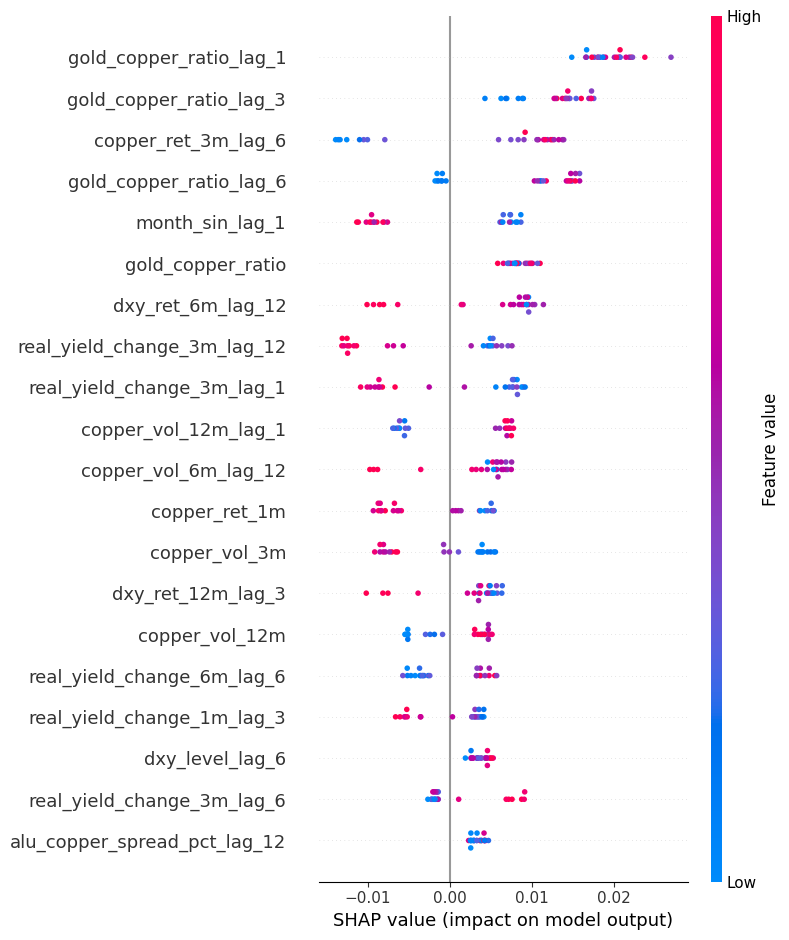

SHAP beeswarm saved to /kaggle/working/outputs_monthly/shap_beeswarm.png
Top 10 features by mean |SHAP|:
gold_copper_ratio_lag_1        0.019614
gold_copper_ratio_lag_3        0.012719
copper_ret_3m_lag_6            0.011128
gold_copper_ratio_lag_6        0.009388
month_sin_lag_1                0.008376
gold_copper_ratio              0.008361
dxy_ret_6m_lag_12              0.008288
real_yield_change_3m_lag_12    0.008130
real_yield_change_3m_lag_1     0.007768
copper_vol_12m_lag_1           0.006544


In [28]:
try:
    import shap, matplotlib.pyplot as plt
    shap.initjs()

    xgb_shap = make_xgb()
    xgb_shap.fit(X_dev_pruned, y_dev)
    explainer = shap.TreeExplainer(xgb_shap._model)
    shap_values = explainer.shap_values(X_hold_pruned)

    fig_shap = plot_shap_summary(shap_values, list(X_hold_pruned.columns), top_n=20)
    fig_shap.show()

    shap.summary_plot(shap_values, X_hold_pruned, max_display=20, show=False)
    plt.tight_layout()
    _bp = os.path.join(CFG['output_dir'], 'shap_beeswarm.png')
    plt.savefig(_bp, dpi=150, bbox_inches='tight'); plt.show()
    print(f'SHAP beeswarm saved to {_bp}')

    mean_abs_shap = pd.Series(
        np.abs(shap_values).mean(axis=0), index=X_hold_pruned.columns
    ).sort_values(ascending=False)
    print('Top 10 features by mean |SHAP|:')
    print(mean_abs_shap.head(10).to_string())
except Exception as e:
    print(f'SHAP skipped: {e}')


## 12. Interactive Plotly Visualisations

In [29]:
best_cv_df = cv_results[best_name]
fig_dashboard = plot_dashboard(df_aug, best_cv_df, model_name=best_name)
fig_dashboard.show()

# Rolling signal Sharpe of the SELECTED model (max signal_sharpe — same rule as the
# OOS cell above; this is the model that goes into forecast_summary.json).
oos_best = oos_results[best_oos_name]  # selected in the OOS cell via select_best_model
signal_ret_oos = np.sign(oos_best['y_pred']) * oos_best['y_true']

# 12-month rolling window with monthly annualisation factor
roll_window = 12
rolling_sharpe = (
    signal_ret_oos.rolling(roll_window).mean() /
    signal_ret_oos.rolling(roll_window).std().replace(0, np.nan)
) * np.sqrt(CFG['periods_per_year'] / CFG['primary_horizon'])

fig_sharpe = go.Figure(go.Scatter(
    x=rolling_sharpe.index, y=rolling_sharpe,
    name='Rolling Sharpe (12m)', line=dict(color='#b87333'),
))
fig_sharpe.add_hline(y=0, line_width=1, line_dash='dash', line_color='grey')
fig_sharpe.update_layout(
    title=f'Rolling 12-Month Signal Sharpe — {best_oos_name} ({CFG["primary_horizon"]}d horizon)',
    template='plotly_white', yaxis_title='Annualised Sharpe ratio',
)
fig_sharpe.show()


## 13. Scenario Analysis

Scenarios over a 3-month horizon — credibly long enough for the macro shocks
modeled here to play out, unlike a 1-day variant.

In [30]:
latest_features = X_pruned_full.tail(1)
current_copper  = float(df_aug['copper_price'].iloc[-1])

scenario_model = EnsembleModel([make_xgb(), make_lgb()])
scenario_model.fit(X_dev_pruned, y_dev)

engine = ScenarioEngine(
    model=scenario_model,
    feature_template=latest_features,
    copper_price_current=current_copper,
    horizon=CFG['primary_horizon'],
)
print(f'Current copper price       : ${current_copper:,.0f}/t')
print(f'Baseline {CFG["primary_horizon"]}-month forecast: ${engine.base_price:,.0f}/t')

scenario_report = engine.report()
print('\n── Scenario Report (monthly model) ──')
print(scenario_report.to_string())

fig_tornado = plot_scenario_tornado(
    base_forecast=engine.base_price,
    scenario_results={row.Index: row.scenario_price for row in scenario_report.itertuples()},
)
fig_tornado.show()


WARNING | Shock target 'dxy_ret_22d' not in feature set — skipped.
WARNING | Shock target 'real_yield_change_22d' not in feature set — skipped.
WARNING | Shock target 'sp500_ret_22d' not in feature set — skipped.
INFO | Scenario 'bull_strong': base=14389  forecast=14389  delta=-0 (-0.0%)
WARNING | Shock target 'dxy_ret_22d' not in feature set — skipped.
WARNING | Shock target 'real_yield_change_22d' not in feature set — skipped.
WARNING | Shock target 'sp500_ret_22d' not in feature set — skipped.
INFO | Scenario 'bear_strong': base=14389  forecast=14379  delta=-10 (-0.1%)
WARNING | Shock target 'sp500_ret_22d' not in feature set — skipped.
WARNING | Shock target 'cny_usd_level' not in feature set — skipped.
INFO | Scenario 'china_demand_surge': base=14389  forecast=14389  delta=-0 (-0.0%)
WARNING | Shock target 'copper_ret_1d' not in feature set — skipped.
WARNING | Shock target 'copper_vol_22d' not in feature set — skipped.
WARNING | Shock target 'bb_width' not in feature set — skippe

Current copper price       : $13,827/t
Baseline 3-month forecast: $14,389/t

── Scenario Report (monthly model) ──
                            base_price  scenario_price  delta  delta_pct
scenario                                                                
bear_strong                   14389.11        14379.27  -9.84      -0.07
bull_strong                   14389.11        14388.89  -0.23      -0.00
china_demand_surge            14389.11        14388.89  -0.23      -0.00
supply_disruption             14389.11        14389.11   0.00       0.00
comex_inventory_drop_40pct    14389.11        14389.11   0.00       0.00
high_inflation                14389.11        14389.11   0.00       0.00
us_tariff_shock               14389.11        14389.11   0.00       0.00


In [31]:
# DXY sensitivity sweep — uses dxy_ret_3m if present, else falls back to first
# available dxy return feature so it works regardless of the CFG['return_lags'] choice.
_dxy_candidates = [c for c in X_pruned_full.columns if c.startswith('dxy_ret_')]
if _dxy_candidates:
    sweep_col = next((c for c in _dxy_candidates if c.endswith('3m')), _dxy_candidates[0])
    dxy_shocks = np.linspace(-0.10, 0.10, 21)
    sweep_dxy  = engine.sweep(sweep_col, dxy_shocks.tolist(), label=f'{sweep_col} shock')
    fig_sweep  = go.Figure(go.Scatter(
        x=sweep_dxy['shock'], y=sweep_dxy['forecast_price'],
        mode='lines+markers', line=dict(color='#b87333'), name='Forecast price',
    ))
    fig_sweep.add_hline(y=engine.base_price, line_dash='dash', line_color='grey',
                        annotation_text='Baseline')
    fig_sweep.update_layout(
        title=f'Copper price sensitivity to {sweep_col}',
        xaxis_title=f'{sweep_col} shock (additive)',
        yaxis_title='Forecast Copper Price ($/t)',
        template='plotly_white',
    )
    fig_sweep.show()
else:
    print('No dxy_ret_* feature in pruned set — skipping DXY sweep.')

# Custom geopolitical / tariff shock (scaled to monthly magnitudes)
shock_kwargs = {}
for k, v in {'dxy_ret_3m': 0.04, 'sp500_ret_3m': -0.08,
             'copper_vol_3m': 0.05, 'real_yield_change_3m': 0.3}.items():
    if k in X_pruned_full.columns:
        shock_kwargs[k] = v
if shock_kwargs:
    result = engine.run('geo_tariff_shock', shocks=shock_kwargs)
    print('\nCustom scenario result:')
    for k, v in result.items():
        print(f'  {k}: {v}')
else:
    print('No matching shock features in pruned set — skipping custom scenario.')


INFO | Scenario 'geo_tariff_shock': base=14389  forecast=14362  delta=-27 (-0.2%)



Custom scenario result:
  scenario: geo_tariff_shock
  base_price: 14389.11
  scenario_price: 14362.01
  delta: -27.1
  delta_pct: -0.19


## 14. Export Results

In [32]:
import json
from datetime import date

out_dir = CFG['output_dir']

forecast_df.to_csv(os.path.join(out_dir, 'forecast_multi_horizon.csv'))
ci_walk.reset_index().rename(columns={'index': 'date'}).to_csv(
    os.path.join(out_dir, 'forecast_ci_walk.csv'), index=False
)

for name, df_oos in oos_results.items():
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
    df_oos.to_csv(os.path.join(out_dir, f'oos_{safe_name}.csv'))

oos_summary.to_csv(os.path.join(out_dir, 'model_comparison.csv'))
scenario_report.to_csv(os.path.join(out_dir, 'scenario_report.csv'))
coint_df.to_csv(os.path.join(out_dir, 'cointegration_results.csv'))

summary_json = {
    'generated_at':       date.today().isoformat(),
    'frequency':          'monthly',
    'current_price':      round(current_copper, 2),
    'primary_horizon_m':  CFG['primary_horizon'],
    'horizons_m':         CFG['horizons'],
    'baseline_forecast':  round(engine.base_price, 2),
    'best_model':         best_oos_name,
    'oos_metrics':        oos_metrics[best_oos_name],
    'multi_horizon_forecast': {int(k): {kk: float(vv) for kk, vv in v.items()}
                               for k, v in forecast_df.to_dict(orient='index').items()},
    'scenarios':          scenario_report.reset_index().to_dict(orient='records'),
}
with open(os.path.join(out_dir, 'forecast_summary.json'), 'w') as f:
    json.dump(summary_json, f, indent=2, default=float)

print(f'All outputs saved to {out_dir}/')
print('Files:', sorted(os.listdir(out_dir)))


All outputs saved to /kaggle/working/outputs_monthly/
Files: ['cointegration_results.csv', 'forecast_ci_walk.csv', 'forecast_multi_horizon.csv', 'forecast_summary.json', 'model_comparison.csv', 'oos_ARIMAX101.csv', 'oos_LightGBM.csv', 'oos_Linear_Ridge.csv', 'oos_Naive_RW.csv', 'oos_Prophet.csv', 'oos_StackingXGBoost+LightGBM+Prophet.csv', 'oos_XGBoost.csv', 'scenario_report.csv', 'shap_beeswarm.png']


---
## Email forecast pipeline

In [33]:
# ── Email forecast results after pipeline run ────────────────────────────────
import smtplib, os
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders


def send_email_with_attachments(sender_email, sender_password, receiver_email,
                                subject, body, attachments):
    msg = MIMEMultipart()
    msg['From']    = sender_email
    msg['To']      = receiver_email
    msg['Subject'] = subject
    msg.attach(MIMEText(body, 'plain'))

    for item in attachments:
        if isinstance(item, (tuple, list)):
            file_path, attached_name = item
        else:
            file_path, attached_name = item, None
        if not os.path.exists(file_path):
            print(f'  Skipping missing attachment: {file_path}')
            continue
        with open(file_path, 'rb') as f:
            part = MIMEBase('application', 'octet-stream')
            part.set_payload(f.read())
        encoders.encode_base64(part)
        if attached_name is None:
            attached_name = os.path.basename(file_path)
        elif not os.path.splitext(attached_name)[1]:
            attached_name += os.path.splitext(file_path)[1]
        part.add_header('Content-Disposition',
                        f'attachment; filename={attached_name}')
        msg.attach(part)

    with smtplib.SMTP_SSL('smtp.gmail.com', 465) as server:
        server.login(sender_email, sender_password)
        server.send_message(msg)
    print(f'Email sent to {receiver_email}')


def save_figure(fig, png_path):
    try:
        fig.write_image(png_path, scale=2)
        print(f'Saved {os.path.basename(png_path)}')
        return png_path
    except Exception as e:
        print(f'Could not save {os.path.basename(png_path)}: {e}')
        html_path = png_path.replace('.png', '.html')
        fig.write_html(html_path)
        print(f'  Saved fallback {os.path.basename(html_path)}')
        return html_path


def _safe_model_name(name):
    return (name.replace(' ', '_').replace('(', '').replace(')', '')
                .replace('/', '_').replace('+', 'plus').replace(',', ''))


# ── Resolve the forecast horizon to a monthly label ──────────────────────────
_h          = CFG['primary_horizon']
horizon_label = f'{_h} month' + ('s' if _h != 1 else '')
horizon_tag   = f'{_h}m'

as_of_dt    = df_aug.index[-1]
target_dt   = as_of_dt + pd.DateOffset(months=_h)
as_of_str   = as_of_dt.date().isoformat()
target_str  = target_dt.date().isoformat()

out_dir = CFG['output_dir']
saved_fc   = save_figure(fig_fc,  os.path.join(out_dir, 'forecast_ci.png'))
saved_cmp  = save_figure(fig_cmp, os.path.join(out_dir, 'model_comparison.png'))
fig_best   = plot_cv_results(oos_results[best_oos_name], model_name=f'{best_oos_name} (OOS)')
saved_best = save_figure(fig_best, os.path.join(out_dir, 'best_model_oos.png'))

_safe_best   = _safe_model_name(best_oos_name)
_attachments = [
    (saved_fc,  f'forecast_ci_{horizon_tag}_QuantileForecaster.png'),
    (saved_cmp, f'model_comparison_oos_{horizon_tag}_all_candidates.png'),
    (saved_best, f'oos_folds_{_safe_best}_{horizon_tag}.png'),
    (os.path.join(out_dir, 'shap_beeswarm.png'),
     'shap_beeswarm_XGBoost_explainability.png'),
]


# ── Load email credentials from Kaggle Secrets ───────────────────────────────
try:
    from kaggle_secrets import UserSecretsClient
    _secrets        = UserSecretsClient()
    sender_email    = _secrets.get_secret('GMAIL_ADDRESS')
    sender_password = _secrets.get_secret('GMAIL_APP_PASSWORD')
except Exception as e:
    raise RuntimeError(f'Email secrets not found — add GMAIL_ADDRESS and GMAIL_APP_PASSWORD to Kaggle Secrets. ({e})')


_sel = oos_summary.loc[best_oos_name]

# Multi-horizon forecast block in the body
_mh_lines = []
for h_row in forecast_df.reset_index().itertuples():
    _mh_lines.append(
        f"  {h_row.horizon_months}m: median ${h_row.median:,.0f}/t  "
        f"(80% CI ${h_row.lower:,.0f} – ${h_row.upper:,.0f})"
    )
_mh_block = '\n'.join(_mh_lines)

email_body = (
    f'Copper Forecast Pipeline (MONTHLY) complete.\n'
    f'Forecast horizon : {horizon_label}\n'
    f'Data as of       : {as_of_str}\n'
    f'Forecast for     : {target_str}  (= as-of + {_h} months)\n'
    f'\n'
    f'Selected model   : {best_oos_name}  (max OOS signal_sharpe — used for the forecast)\n'
    f'  signal_sharpe        : {_sel["signal_sharpe"]:+.3f}\n'
    f'  directional_accuracy : {_sel["directional_accuracy"]:.3f}\n'
    f'  rmse_skill vs Naive  : {_sel["rmse_skill"]:+.4f}\n'
    f'  rmse                 : {_sel["rmse"]:.4f}\n'
    f'CV-stage winner  : {best_name}  (informational only)\n'
    f'\n'
    f'Current price    : ${current_copper:,.0f}/t\n'
    f'Baseline forecast: ${engine.base_price:,.0f}/t  ({horizon_label})\n'
    f'\n'
    f'Multi-horizon forecast (median + 80% CI):\n{_mh_block}\n'
    f'\n'
    f'Attachments (model annotated in each filename):\n'
    f'  - forecast_ci_{horizon_tag}_QuantileForecaster.png (CI walk over the holdout)\n'
    f'  - model_comparison_oos_{horizon_tag}_all_candidates.png\n'
    f'  - oos_folds_{_safe_best}_{horizon_tag}.png\n'
    f'  - shap_beeswarm_XGBoost_explainability.png\n'
)

send_email_with_attachments(
    sender_email    = sender_email,
    sender_password = sender_password,
    receiver_email  = sender_email,
    subject         = f'Copper Forecast (Weekly) — {horizon_label} — {best_oos_name} ({as_of_str})',
    body            = email_body,
    attachments     = _attachments,
)


Saved forecast_ci.png
Saved model_comparison.png
Saved best_model_oos.png
Email sent to ferhat00@gmail.com
